In [1]:
import datetime as dt
import dask.dataframe as dd
import pandas as pd
import dask
from sqlalchemy import select, create_engine
from sqlalchemy.engine import Engine
from sqlalchemy.sql.expression import func
from sqlalchemy.sql.expression import literal_column, literal
from sqlalchemy.dialects.postgresql import INTERVAL
from dotenv import load_dotenv
import os
from statsmodels.tsa.stattools import coint
import mc_postgres_db.models as models
from sqlalchemy.orm import Session
from dask.distributed import Client

load_dotenv()

POSTGRES_URL = os.getenv("POSTGRES_URL")

engine = create_engine(POSTGRES_URL)

In [23]:
client = Client(n_workers=8)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 16,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55413,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:55438,Total threads: 2
Dashboard: http://127.0.0.1:55449/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:55416,


In [3]:
date: dt.date = dt.datetime.now(dt.timezone.utc).date() - dt.timedelta(days=1)
end = dt.datetime.combine(date, dt.time.min)
start = end - dt.timedelta(days=1)
start_naive = start.replace(tzinfo=None).replace(second=0, microsecond=0)
end_naive = end.replace(tzinfo=None).replace(second=0, microsecond=0)
print(f"Start: {start}, End: {end}")

Start: 2025-10-28 00:00:00, End: 2025-10-29 00:00:00


In [4]:
max_groups = 5
with Session(engine) as session:
    # Get all provider asset group id(s)
    provider_asset_group_ids = session.scalars(
        select(models.ProviderAssetGroup.id).limit(max_groups)
    ).all()
print(
    f"Provider asset group ids (count: {len(provider_asset_group_ids)}): {provider_asset_group_ids}"
)

Provider asset group ids (count: 5): [1, 2, 3, 4, 5]


In [28]:
client.compute(dd.read_sql_table(
    "provider_asset_group",
    engine.url.render_as_string(hide_password=False),
    index_col="id",
    bytes_per_chunk="512 MiB",
))

<Future: pending, key: ('fromdelayed-b55fd3ac6c487435090002a16d44e1c9', 0)>

In [58]:
# Now select from the subquery
time_frame: dd.DataFrame = dd.read_sql_query(
    select(select(
    func.generate_series(
        literal_column(start_naive.strftime("'%Y-%m-%d %H:%M:%S'::timestamp")),
        literal_column(end_naive.strftime("'%Y-%m-%d %H:%M:%S'::timestamp")),
        func.cast(literal("1 minute"), INTERVAL),
    ).label("timestamp")
).subquery("time_frame_temp")),
    engine.url.render_as_string(hide_password=False),
    index_col="timestamp",
    bytes_per_chunk="512 MiB",
)

In [59]:
provider_asset_group_members = dd.read_sql_table(
    "provider_asset_group_member",
    engine.url.render_as_string(hide_password=False),
    index_col="provider_asset_group_id",
    bytes_per_chunk="512 MiB",
)

In [61]:
time_frame.join(
    provider_asset_group_members,
    how="cross",
)

ValueError: dask.dataframe.merge does not support how='cross'.Options are: ('left', 'right', 'outer', 'inner', 'leftsemi').

In [ ]:
# Create subquery that generates minutely timestamps using PostgreSQL's generate_series
start_str = start_naive.strftime("'%Y-%m-%d %H:%M:%S'::timestamp")
end_str = end_naive.strftime("'%Y-%m-%d %H:%M:%S'::timestamp")
time_frame_subquery = select(
    func.generate_series(
        literal_column(start_str),
        literal_column(end_str),
        func.cast(literal("1 minute"), INTERVAL),
    ).label("timestamp")
).subquery("time_frame")

# Create the sub-query for all provider asset group members.
provider_asset_group_members_subquery = (
    select(
        models.ProviderAssetGroupMember.provider_asset_group_id,
        models.ProviderAssetGroupMember.order,
        models.ProviderAssetGroupMember.provider_id,
        models.ProviderAssetGroupMember.from_asset_id,
        models.ProviderAssetGroupMember.to_asset_id,
    )
    .where(
        models.ProviderAssetGroupMember.provider_asset_group_id.in_(
            provider_asset_group_ids
        )
    )
    .subquery("provider_asset_group_members")
)

# Combine the time-frame with the provider asset group members into a dask dataframe.
# Using cross join to create a complete timeframe for each asset group member
# Wrap in an additional subquery to help Dask partition correctly
full_frame_inner = select(
    time_frame_subquery.c.timestamp,
    provider_asset_group_members_subquery.c.provider_asset_group_id,
    provider_asset_group_members_subquery.c.order,
    provider_asset_group_members_subquery.c.provider_id,
    provider_asset_group_members_subquery.c.from_asset_id,
    provider_asset_group_members_subquery.c.to_asset_id,
).select_from(
    time_frame_subquery.join(
        provider_asset_group_members_subquery, literal(True), isouter=False
    )
).subquery("full_frame_inner")

# Select from the subquery for Dask
full_frame_query = select(
    full_frame_inner.c.timestamp,
    full_frame_inner.c.provider_asset_group_id,
    full_frame_inner.c.order,
    full_frame_inner.c.provider_id,
    full_frame_inner.c.from_asset_id,
    full_frame_inner.c.to_asset_id,
).order_by(full_frame_inner.c.timestamp)

full_frame: dd.DataFrame = dd.read_sql_query(
    full_frame_query,
    engine.url.render_as_string(hide_password=False),
    index_col="timestamp",
    bytes_per_chunk="512 MiB",
)


# Get the market data Dask dataframe.
market_data: dd.DataFrame = dd.read_sql_query(
    select(
        models.ProviderAssetMarket.timestamp,
        models.ProviderAssetMarket.provider_id,
        models.ProviderAssetMarket.from_asset_id,
        models.ProviderAssetMarket.to_asset_id,
        models.ProviderAssetMarket.close,
    )
    .where(models.ProviderAssetMarket.timestamp.between(start_naive, end_naive))
    .order_by(models.ProviderAssetMarket.timestamp),
    engine.url.render_as_string(hide_password=False),
    index_col="timestamp",
    bytes_per_chunk="512 MiB",
)

# As-of join the market data with the full frame.
framed_market_data = dd.merge_asof(
    full_frame,
    market_data,
    left_index=True,
    right_index=True,
    by=["provider_id", "from_asset_id", "to_asset_id"],
)

# Split out the close for each order and create pairs-trading frame.
close_1 = framed_market_data.loc[
    full_frame["order"] == 1,
    ["provider_asset_group_id", "provider_id", "from_asset_id", "to_asset_id", "close"],
]
close_2 = framed_market_data.loc[
    full_frame["order"] == 2,
    ["provider_asset_group_id", "provider_id", "from_asset_id", "to_asset_id", "close"],
]
pairs_trading_frame: dd.DataFrame = dd.merge(
    close_1,
    close_2,
    on=["timestamp", "provider_asset_group_id"],
    how="inner",
    suffixes=("_1", "_2"),
)

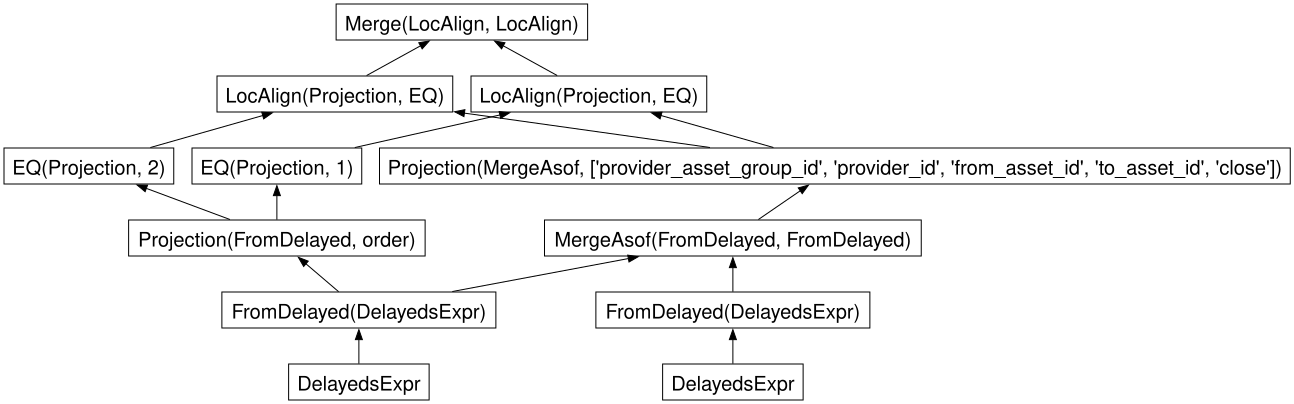

In [22]:
pairs_trading_frame.visualize()

### Optional: Installing Graphviz for Visualization

If you want to use `.visualize()` to see Dask computation graphs, install Graphviz:

**On macOS:**
```bash
brew install graphviz
```

**On Ubuntu/Debian:**
```bash
sudo apt-get install graphviz
```

**On Windows:**
Download from https://graphviz.org/download/ and add to PATH

Then install the Python package:
```bash
pip install graphviz
```


In [19]:
cointegration_p_values = pairs_trading_frame.groupby(
    "provider_asset_group_id"
)[["close_1", "close_2"]].apply(
    lambda df: pd.Series(coint(df["close_1"], df["close_2"])[1], index=["p_value"]),
    meta={
        "p_value" : pd.Series([], dtype=float)
    }
)
cointegration_p_values.compute()

,p_value
provider_asset_group_id,
1,0.541654
2,0.561820
3,0.060448
4,0.003039
5,0.374939


In [7]:
cointegration_p_values

provider_asset_group_id
1    0.541654
2    0.561820
3    0.060448
4    0.003039
5    0.374939
Name: p_value, dtype: float64

In [11]:
def get_pairs_trading_frame(start: dt.datetime, end: dt.datetime, provider_asset_group_ids: list[int], url: str) -> pd.DataFrame:
    """
    Get the pairs trading frame for the given start and end dates and provider asset group ids.
    """

    # Create subquery that generates minutely timestamps using PostgreSQL's generate_series
    start_str = start_naive.strftime("'%Y-%m-%d %H:%M:%S'::timestamp")
    end_str = end_naive.strftime("'%Y-%m-%d %H:%M:%S'::timestamp")
    time_frame_subquery = select(
        func.generate_series(
            literal_column(start_str),
            literal_column(end_str),
            func.cast(literal("1 minute"), INTERVAL),
        ).label("timestamp")
    ).subquery("time_frame")

    # Create the sub-query for all provider asset group members.
    provider_asset_group_members_subquery = (
        select(
            models.ProviderAssetGroupMember.provider_asset_group_id,
            models.ProviderAssetGroupMember.order,
            models.ProviderAssetGroupMember.provider_id,
            models.ProviderAssetGroupMember.from_asset_id,
            models.ProviderAssetGroupMember.to_asset_id,
        )
        .where(
            models.ProviderAssetGroupMember.provider_asset_group_id.in_(
                provider_asset_group_ids
            )
        )
        .subquery("provider_asset_group_members")
    )

    # Combine the time-frame with the provider asset group members into a dask dataframe.
    # Using cross join to create a complete timeframe for each asset group member
    full_frame: pd.DataFrame = pd.read_sql_query(
        select(
            time_frame_subquery.c.timestamp,
            provider_asset_group_members_subquery.c.provider_asset_group_id,
            provider_asset_group_members_subquery.c.order,
            provider_asset_group_members_subquery.c.provider_id,
            provider_asset_group_members_subquery.c.from_asset_id,
            provider_asset_group_members_subquery.c.to_asset_id,
        )
        .select_from(
            time_frame_subquery.join(
                provider_asset_group_members_subquery, literal(True), isouter=False
            )
        )
        .order_by(time_frame_subquery.c.timestamp),
        engine,
        index_col="timestamp"
    )

    # Get the market data Dask dataframe.
    market_data: pd.DataFrame = pd.read_sql_query(
        select(
            models.ProviderAssetMarket.timestamp,
            models.ProviderAssetMarket.provider_id,
            models.ProviderAssetMarket.from_asset_id,
            models.ProviderAssetMarket.to_asset_id,
            models.ProviderAssetMarket.close,
        )
        .where(models.ProviderAssetMarket.timestamp.between(start_naive, end_naive))
        .order_by(models.ProviderAssetMarket.timestamp),
        engine,
        index_col="timestamp"
    )

    # As-of join the market data with the full frame.
    full_frame = pd.merge_asof(
        full_frame,
        market_data,
        left_index=True,
        right_index=True,
        by=["provider_id", "from_asset_id", "to_asset_id"],
    )

    # Split out the close for each order and create pairs-trading frame.
    close_1 = full_frame.loc[
        full_frame["order"] == 1,
        ["provider_asset_group_id", "provider_id", "from_asset_id", "to_asset_id", "close"],
    ]
    close_2 = full_frame.loc[
        full_frame["order"] == 2,
        ["provider_asset_group_id", "provider_id", "from_asset_id", "to_asset_id", "close"],
    ]
    return pd.merge(
        close_1,
        close_2,
        on=["timestamp", "provider_asset_group_id"],
        how="inner",
        suffixes=("_1", "_2"),
    )